In [27]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import matplotlib.pyplot as plt


Loading in the data

In [28]:
df_recipes = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-09-16/all_recipes.csv')
df_cuisines = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-09-16/cuisines.csv')

Check number of entries in each dataset
- no. of entries = no. of unique urls means 'url' can be used as a key
- much less entries in the cuisine dataset means we should only use the merged cuisine dataset for the first visualisation

In [29]:
print(f"Recipes data shape: {df_recipes.shape}")
print(f"Cuisines data shape: {df_cuisines.shape}")
print(f"Unique URLs in Recipes: {df_recipes['url'].nunique()}")
print(f"Unique URLs in Cuisines: {df_cuisines['url'].nunique()}")

Recipes data shape: (14426, 16)
Cuisines data shape: (2218, 17)
Unique URLs in Recipes: 14426
Unique URLs in Cuisines: 2218


Columns of concern are 'url', 'date_published', 'protein', 'calories', 'avg_rating', 'prep_time', 'name'.

Check for their type, as well as missing entries

In [30]:
print(df_recipes[['url', 'date_published', 'protein', 'calories', 'avg_rating', 'prep_time', 'name']].dtypes)
print(df_cuisines[['url', 'country']].dtypes)
critical_cols = ['url', 'date_published', 'protein', 'calories', 'avg_rating', 'prep_time', 'name']
print(df_recipes[critical_cols].isnull().sum())

url                object
date_published     object
protein           float64
calories          float64
avg_rating        float64
prep_time           int64
name               object
dtype: object
url        object
country    object
dtype: object
url                 0
date_published      0
protein           248
calories          200
avg_rating        972
prep_time           0
name                0
dtype: int64


Preview the data for the important columns.
- Protein value of 0 means that there will be protein/calorie ratio of 0
- Prep time of 0 might need to be filtered out
- Unusally high and low prep times may be problematic when visualising

In [31]:
df_subset = df_recipes[critical_cols]

print("Numeric data info")

numeric_summary = df_subset.select_dtypes(include='number').agg(['min', 'max'])
print(numeric_summary)


print("\nNon-numeric data info")
non_numeric_cols = df_subset.select_dtypes(exclude='number').columns
for col in non_numeric_cols:
    # Get total count of unique items
    unique_count = df_subset[col].nunique()
    
    # Get the actual text values, ignoring NaNs
    unique_values = df_subset[col].dropna().unique()
    
    print(f"\nColumn: '{col}'")
    print(f"Total Unique Values: {unique_count}")
    
    # Print only the first 10 values to keep the output clean
    print(f"Sample Values: {unique_values[:10]}")

Numeric data info
     protein  calories  avg_rating  prep_time
min      0.0       1.0         1.0          0
max    939.0    9538.0         5.0       2160

Non-numeric data info

Column: 'url'
Total Unique Values: 14426
Sample Values: ['https://www.allrecipes.com/recipe/140717/chewy-whole-wheat-peanut-butter-brownies/'
 'https://www.allrecipes.com/recipe/269204/pumpkin-pie-eggnog/'
 'https://www.allrecipes.com/recipe/238054/eggs-poached-in-tomato-sauce/'
 'https://www.allrecipes.com/minestrone-casserole-recipe-8765618'
 'https://www.allrecipes.com/recipe/241937/yummy-stuffed-peppers/'
 'https://www.allrecipes.com/recipe/219586/prime-rib-our-way/'
 'https://www.allrecipes.com/recipe/8636/parmesan-chicken-ii/'
 'https://www.allrecipes.com/recipe/12950/chicken-andouille-gumbo/'
 'https://www.allrecipes.com/recipe/185816/sweet-pork-for-burritos/'
 'https://www.allrecipes.com/recipe/239507/quick-baked-chicken-parmesan/']

Column: 'date_published'
Total Unique Values: 1542
Sample Values: ['

Check for number of unique cuisines

In [32]:
print(f"Sample of unique cuisines: {df_cuisines['country'].dropna().unique()[:10]}")

Sample of unique cuisines: ['Greek' 'Jewish' 'Australian and New Zealander' 'Chilean' 'Tex-Mex'
 'Canadian' 'Italian' 'Danish' 'Amish and Mennonite' 'Spanish']


Check for duplicate data, no duplicates found

In [33]:
print(f"Duplicate rows in Recipes: {df_recipes.duplicated().sum()}")
print(f"Duplicate rows in Cuisines: {df_cuisines.duplicated().sum()}")

Duplicate rows in Recipes: 0
Duplicate rows in Cuisines: 0


Since we are merging cuisines.csv with all_recipes.csv, check how many urls actually match.

Final merged df will have 1055 or less entries.

In [34]:
matches = df_cuisines['url'].isin(df_recipes['url']).sum()
total_cuisines = len(df_cuisines['url'])

print(f"Matching URLs: {matches} out of {total_cuisines}")

Matching URLs: 1055 out of 2218


Create a subset of all_recipes.csv with only the necessary columns and dropping all missing data. We are left with 13232/14426 entries.

In [35]:
df_base = df_subset.dropna(subset=critical_cols)
df_base.shape

(13232, 7)

Data type conversion:
- datetime for date
- category for country

In [36]:
df_base['date_published'] = pd.to_datetime(df_base['date_published'], format='%Y-%m-%d')
df_cuisines['country'] = df_cuisines['country'].astype('category')

C:\Users\seand\AppData\Local\Temp\ipykernel_2168\2858831330.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Create protein_calorie_ratio column

In [37]:
df_base['protein_calorie_ratio'] = df_base['protein'] / df_base['calories']

C:\Users\seand\AppData\Local\Temp\ipykernel_2168\3928749409.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Create merged df for 1st visualisation

In [38]:
df_merged = pd.merge(df_base, 
                    df_cuisines[['url', 'country']], 
                    on='url', 
                    how='inner')

df_merged = df_merged.dropna(subset=['country'])

Preview of the cleaned data
- df_base is before merging, for Viz 2 and Viz 3
- df_merged is after merging with country data, for Viz 1

In [39]:
print(f"Cleaned dataset: {df_base.shape}")
display(df_base.head())

print(f"\nCleaned dataset after merger: {df_merged.shape}")
display(df_merged.head())

Cleaned dataset: (13232, 8)


,url,date_published,protein,calories,avg_rating,prep_time,name,protein_calorie_ratio
0,https://www.allrecipes.com/recipe/140717/chewy...,2020-06-18,6.0,222.0,4.4,20,Chewy Whole Wheat Peanut Butter Brownies,0.027027
1,https://www.allrecipes.com/recipe/269204/pumpk...,2022-09-26,8.0,477.0,5.0,10,Pumpkin Pie Eggnog,0.016771
2,https://www.allrecipes.com/recipe/238054/eggs-...,2018-06-08,20.0,354.0,4.8,10,Eggs Poached in Tomato Sauce,0.056497
3,https://www.allrecipes.com/minestrone-casserol...,2025-03-03,19.0,356.0,4.3,20,Minestrone Casserole,0.053371
4,https://www.allrecipes.com/recipe/241937/yummy...,2024-12-11,19.0,366.0,4.7,30,Yummy Stuffed Peppers,0.051913



Cleaned dataset after merger: (1001, 9)


,url,date_published,protein,calories,avg_rating,prep_time,name,protein_calorie_ratio,country
0,https://www.allrecipes.com/recipe/282434/quinc...,2020-11-30,3.0,188.0,5.0,30,Quince Empanadas,0.015957,Argentinian
1,https://www.allrecipes.com/recipe/220128/chef-...,2024-01-19,66.0,1262.0,4.5,15,Chef John's Buttermilk Fried Chicken,0.052298,Soul Food
2,https://www.allrecipes.com/recipe/259179/polis...,2024-11-23,10.0,581.0,5.0,25,Polish Poppy Seed Cake,0.017212,Polish
3,https://www.allrecipes.com/recipe/45301/harose...,2025-03-20,4.0,241.0,4.8,20,Haroset for Passover,0.016598,Jewish
4,https://www.allrecipes.com/chicken-marsala-fet...,2024-03-11,57.0,861.0,4.6,15,Chicken Marsala Fettuccine,0.066202,Italian


We want to produce a heatmap of protein/calorie ratio against year, grouped by country. This tells us how the protein-calorie ratio varies over the years for each countries cuisine. First, we create a year column from date_published. We group data by country and year, at the same time we remove the rows with less than 3 years of data as that provides limited insight in trends. Then, we perform an aggregation on protein/calorie ratio, grouped by year and country.

In [40]:
df_heatmap=df_merged.copy()
#extract year from date_published
df_heatmap['year']= df_heatmap['date_published'].dt.year

# filter countries with >= 3 years
df_heatmap = df_heatmap[
    df_heatmap.groupby('country')['year'].transform('nunique') >= 3
]

# aggregation
heatmap_data = (
    df_heatmap
    .groupby(['year', 'country'])['protein_calorie_ratio']
    .median()
    .reset_index()
)



C:\Users\seand\AppData\Local\Temp\ipykernel_2168\1138740851.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\seand\AppData\Local\Temp\ipykernel_2168\1138740851.py:13: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [41]:
pivot_heatmap_data = heatmap_data.pivot(index= 'country', columns= 'year', values= 'protein_calorie_ratio')
pivot_heatmap_data = pivot_heatmap_data.dropna(how='all')



In [42]:

#Standardising the data allows the heatmap to highlight relative differences rather than absolute values. In the case of protein-calorie ratios, the raw values are all positive and fall within a relatively narrow range (0,0.0.177515), which can make variation difficult to see. By applying StandardScaler, each value is transformed into a standard score (z-score), expressing how far it lies above or below the mean of the column.
scaler = StandardScaler()
heatmap_data_scaled = scaler.fit_transform(pivot_heatmap_data)

In [43]:

heatmap_data_scaled = pd.DataFrame(
    heatmap_data_scaled,
    index = pivot_heatmap_data.index,
    columns = pivot_heatmap_data.columns
)

heatmap_data_scaled.sort_index(inplace=True)


<Axes: xlabel='year', ylabel='country'>

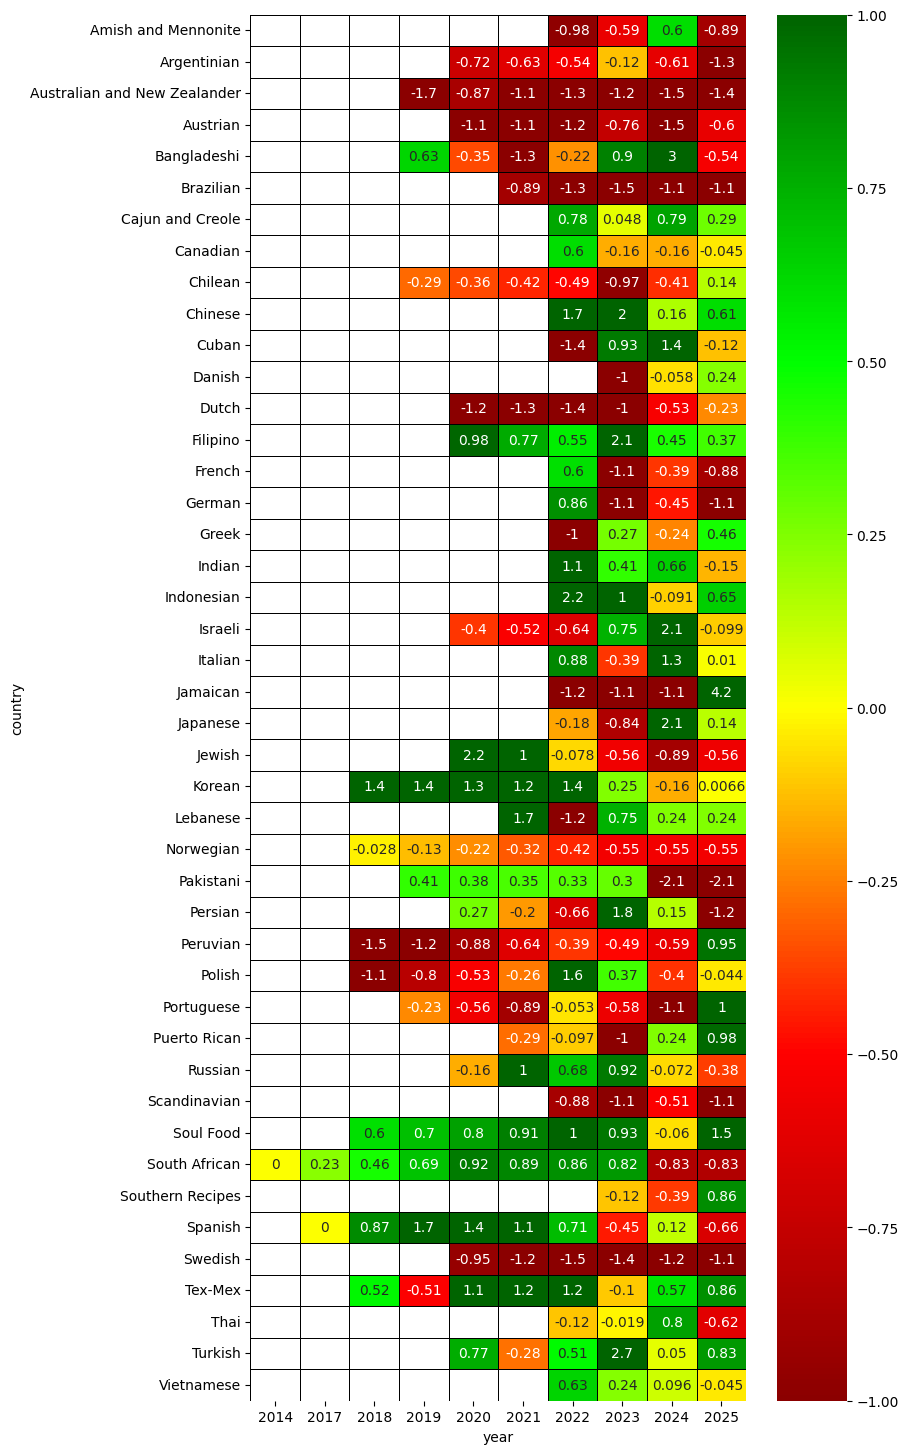

In [44]:
heatmap_filled = heatmap_data_scaled.interpolate(axis=1)

fierce_cmap = LinearSegmentedColormap.from_list(
    "fierce",
    ["#8B0000", "#FF0000", "#FFFF00", "#00FF00", "#006400"]
)

plt.figure(figsize=(8, 18))

sns.heatmap(
    heatmap_filled,
    cmap=fierce_cmap,
    annot=True,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='black'
)

In the earlier years (2014 - 2018), most cuisines are either neutral or negative in protein density 
(predominantly red to yellow gradient), indicating relatively lower protein-to-calorie ratios. 
However, from 2020 onwards, there is a pronounced shift toward positive values (green), with 
many cuisines reaching high protein density levels (approaching +0.5 to +1.0 on the scale) by 
2023 - 2025. For instance, Chinese, Indonesian and Filipino cuisines show strong positive 
values in the later years, with deep green cells indicating consistently high protein ratios. 
Similarly, cuisines such as Cajun and Creole, Soul Food and Tex-Mex exhibit sustained high 
values (above +0.5), suggesting a significant increase in protein density over time. This 
widespread transition across multiple cuisines indicates that the rise in protein-focused diets is 
not isolated but globally pervasive. 

This goes to show that while the early period shows significant dispersion – ranging from 
strongly negative (−1.0) to near neutral – many cuisines cluster in the positive range, 
particularly between +0.4 and +1.0 by 2023 - 2024. Therefore, it indicates that although 
cuisines remain culturally distinct, their nutritional profiles are becoming more similar, with a 
global dietary behaviour converging toward higher protein intake.  
Further comparison also highlighted a differentiated regional patterns in protein-to-calorie ratio 
trend. Asia pacific (APAC) cuisines display some of the strongest upward trends: Chinese, 
Indonesian, Korean, and Indian cuisines all show sustained high values (often above +0.6) in 
the later years, indicating a strong and stable shift toward protein-dense meals. In contrast, 
European cuisines such as French, Italian, and Scandinavian show more variability and often 
remain in negative or only mildly positive ranges. For example, Scandinavian and Swedish 
cuisines remain predominantly red (around −0.5 to −1.0) across most years, indicating 
persistently low protein density. French and Italian cuisines exhibit fluctuations, with 
occasional positive values but lacking the sustained upward trend seen in APAC cuisines. This 
suggests that European cuisines, which traditionally emphasize carbohydrates and fats, were 
slower to adapt to the protein-centric dietary trends in the past decades, compared to APAC 
regions.  

Overall TLDR (I think whoever doing conclusion can use this part): Overall, the heatmap 
provides strong evidence of widespread adaptation within traditional cuisines, with clear 
regional differences in the pace and extent of change. APAC cuisines show the strongest and 
most consistent increases, European cuisines exhibit relative resistance, and American cuisines 
leverage their existing protein-rich structures. This implies that protein-calorie trends are more region-dependent, rather than a global convergence.

In [45]:
country_to_continent = {

    "Amish and Mennonite": "North America", "Canadian": "North America", "Cajun and Creole": "North America", "Cuban": "North America",
    "Jamaican": "North America", "Puerto Rican": "North America", "Soul Food": "North America", "Southern Recipes": "North America", "Tex-Mex": "North America",

    "Argentinian": "South America", "Brazilian": "South America", "Chilean": "South America", "Peruvian": "South America",

    "Austrian": "Europe", "Belgian": "Europe", "Danish": "Europe", "Dutch": "Europe", "Finnish": "Europe", "French": "Europe",
    "German": "Europe", "Greek": "Europe", "Italian": "Europe", "Norwegian": "Europe", "Polish": "Europe", "Portuguese": "Europe",
    "Russian": "Europe", "Scandinavian": "Europe", "Spanish": "Europe", "Swedish": "Europe", "Swiss": "Europe", "Turkish": "Europe",   

    "Bangladeshi": "Asia", "Chinese": "Asia", "Filipino": "Asia", "Indian": "Asia", "Indonesian": "Asia", "Israeli": "Asia",
    "Japanese": "Asia", "Korean": "Asia", "Lebanese": "Asia", "Pakistani": "Asia", "Persian": "Asia", "Thai": "Asia", "Vietnamese": "Asia",

    "South African": "Africa",

    "Australian and New Zealander": "Oceania",

    "Jewish": "Other"
}

df_merged["continent"] = df_merged["country"].map(country_to_continent)
df_merged

,url,date_published,protein,calories,avg_rating,prep_time,name,protein_calorie_ratio,country,continent
0,https://www.allrecipes.com/recipe/282434/quinc...,2020-11-30,3.0,188.0,5.0,30,Quince Empanadas,0.015957,Argentinian,South America
1,https://www.allrecipes.com/recipe/220128/chef-...,2024-01-19,66.0,1262.0,4.5,15,Chef John's Buttermilk Fried Chicken,0.052298,Soul Food,North America
2,https://www.allrecipes.com/recipe/259179/polis...,2024-11-23,10.0,581.0,5.0,25,Polish Poppy Seed Cake,0.017212,Polish,Europe
3,https://www.allrecipes.com/recipe/45301/harose...,2025-03-20,4.0,241.0,4.8,20,Haroset for Passover,0.016598,Jewish,Other
4,https://www.allrecipes.com/chicken-marsala-fet...,2024-03-11,57.0,861.0,4.6,15,Chicken Marsala Fettuccine,0.066202,Italian,Europe
...,...,...,...,...,...,...,...,...,...,...
996,https://www.allrecipes.com/recipe/152243/lolah...,2022-11-09,35.0,265.0,4.7,10,Lolah's Chicken Adobo,0.132075,Filipino,Asia
997,https://www.allrecipes.com/baked-sweet-and-sou...,2024-08-18,53.0,823.0,3.5,20,Baked Sweet And Sour Chicken,0.064399,Chinese,Asia
998,https://www.allrecipes.com/recipe/10192/russia...,2025-03-04,1.0,101.0,4.7,20,Russian Tea Cakes,0.009901,Russian,Europe
999,https://www.allrecipes.com/recipe/75087/spicy-...,2024-11-21,3.0,171.0,4.4,15,"Spicy Indian Green Beans, Gujarati Style",0.017544,Indian,Asia


Keep only the necessary columns

In [46]:
df_bubble = df_merged[
    ["continent", "prep_time", "protein_calorie_ratio"]
].dropna().copy()

Trim extreme prep times to prevent skewing the continent average

In [47]:
upper_limit = df_bubble["prep_time"].quantile(0.99)
df_bubble = df_bubble[df_bubble["prep_time"] <= upper_limit].copy()

Group by continent level

In [48]:
df_bubble = (
    df_bubble.groupby("continent", as_index=False)
    .agg(
        avg_prep_time=("prep_time", "mean"),
        avg_ratio=("protein_calorie_ratio", "mean"),
        recipe_count=("continent", "size")
    )
)

Round the summary columns for cleaner display

In [49]:
df_bubble["avg_prep_time"] = df_bubble["avg_prep_time"].round(1)
df_bubble["avg_ratio"] = df_bubble["avg_ratio"].round(3)

Order the continents

In [50]:
continent_order = [
    "Asia", "Europe", "North America", "South America",
    "Africa", "Oceania", "Other"
]

df_bubble["continent"] = pd.Categorical(
    df_bubble["continent"],
    categories = continent_order,
    ordered = True
)

df_bubble = df_bubble.sort_values("continent")

Preview of final plotting table

In [51]:
df_bubble

,continent,avg_prep_time,avg_ratio,recipe_count
1,Asia,18.9,0.051,319
2,Europe,21.3,0.041,281
3,North America,17.8,0.047,257
6,South America,24.4,0.029,44
0,Africa,22.2,0.045,9
4,Oceania,16.3,0.018,26
5,Other,22.1,0.034,59


In [52]:
fig = px.scatter(
    df_bubble,
    x = "continent",
    y = "avg_prep_time",
    size = "recipe_count",
    color = "avg_ratio",
    size_max = 70,
    color_continuous_scale = "Plasma",
    hover_name="continent",
    hover_data = {
        "avg_prep_time" : ":.1f",
        "avg_ratio" : ":.3f",
        "recipe_count" : True,
        'continent' : False
    },
    labels = {
    "continent" : "Continent / Region",
    "avg_prep_time" : "Average Preparation Time (minutes)",
    "avg_ratio" : "Average Protein-to-Calorie Ratio",
    "recipe_count" : "Number of Recipes"
    },
    title = "Average Preparation Time and Protein-to-Calorie Ratio Across Continents",
)

fig.update_layout(
    template = "simple_white",
    title = dict(
        text = "Average Preparation Time and Protein Density Across Continents",
        x = 0.5,
        xanchor = "center",
        y = 0.96,
        font = dict(size = 22)
    ),
    # Inside fig.update_layout, change the xaxis dict to this:
    xaxis = dict(
        title = "Continent / Region",
        tickmode = "array",
        tickvals = list(range(len(continent_order))), # Use range instead of a dict
        ticktext = continent_order,
        showgrid = False,
        zeroline = False
    ),
    yaxis = dict(
        title = "Average preparation time (minutes)",
        showgrid = True,
        gridcolor = "rgba(0,0,0,0.08)",
        zeroline = False
    ),
    coloraxis = dict(
        colorbar = dict(
            title = "Avg protein-to-calorie ratio",
            thickness = 18,
            len = 0.75,
            y = 0.5
        )
    ),
    font = dict(size = 13),
    width = 1050,
    height = 650,
    margin = dict(t = 110, l = 70, r = 40, b = 70),
    annotations = [
        dict(
            text = "*Bubble size indicates the number of recipes in each continent-level group",
            x = 0.5,
            y = 1.06,
            xref = "paper",
            yref = "paper",
            showarrow = False,
            xanchor = "center",
            font = dict(size = 12, color = "gray")
        )
    ]
)

fig.update_traces(
    marker = dict(
        line = dict(width = 1.2, color = "rgba(255,255,255,0.85)"),
        opacity = 0.82
    )
)
fig.show()

This bubble plot indicates that the relationship between protein density and accessibility varies meaningfully by continent/region. Asia stands out as the region with the highest average Protein-To-Calorie (PTC) ratio at about 0.0510, while still maintaining a relatively short preparation time of 18.9 minutes. This suggests that higher protein consumption is not limited to stereotypically Western "fitness meals". Rather, from this dataset, Asian cuisines appear capable of offering comparatively high-protein recipes without requiring the longest preparation time. This means that higher-protein eating does not necessarily require sacrifising cultural variety.

North American recipes also have good accessibility. Its average PTC ratio is the second highest at about 0.0471, while its average preparation time is only 17.8 minutes, which is the second lowest in the chart. Furthermore, North America is represented by a large bubble, meaning that it contributes a substantial number of recipes. This suggests that protein-dense recipes are not only present, but also prevalent and relatively time-accessible within North American cuisine categories. Together with Asia, this indicates that higher-protein home cooking is supported across more than one major region.

In contrast, Europe shows a different pattern. Despite its large number of recipes, its average PTC ratio is lower, at around 0.0413, while its average preparation time is higher at 21.3 minutes. This suggests that European recipes in the dataset are less protein-dense on average, while also requiring more time to prepare. Thus Europe appears less optimised in terms of protein and accessibility compared to Asia or North America.

South America and Oceania appear less aligned with the high-protein trend. South America has the highest average preparation time at 24.4 minutes but a relatively low average PTC ratio of 0.0286, while Oceania has the lowest at 0.0180 despite one of the shortest preparation times at 16.3 minutes. However, both continents are represented by much smaller bubbles than Asia, Europe, or North Amrica, so these patterns may not be the best representation for their cuisines as a whole.

Africa is also difficult to interpret confidently. Although it shows a fairly high average preparation time of 22.2 minutes and a moderate PTC ratio of 0.0449, it is represented by only 9 recipes. As such, the sample is too small to support a definitive conclusion.

Overall, the plot indicates that high-protein eating does not force people into only a few generic diet-friendly cuisines. The strongest evidence is that Asia and North America both combine relatively high protein density with fairly low preparation time, showing that multiple culinary traditions can support protein-dense cooking. At the same time, the plot does show that this pattern is not equally strong across all regions, so cultural adaptation to high-protein trends may be uneven rather universal.